# Recomendador inicial · tarea 1 — la primera opinión que se escribe en la pizarra

**Qué hace esta herramienta.** Recibe **un único fichero**, `structured-prompt.json`, y
devuelve una predicción con barra de error:

$$A \pm \Delta A \qquad\text{con}\qquad A = p(\text{biopsia}=\texttt{yes})$$

Nada más entra: ni la historia clínica (`*-clinical-data.json`) ni los embeddings. Es una
restricción de diseño, no una carencia — el evaluador del reto puntúa la *precisión* con la
que el agente revela documentos, así que un experto que vive solo del prompt no consume
presupuesto de revelación.

**Qué aporta respecto al análisis previo** (`expertos_analisis/clasificator_for_task.ipynb`):
aquel notebook decidió *qué* clasificador usar; este entrega el **número con su error**, que
es lo que hace falta para que los demás expertos puedan contradecirlo con argumentos.

---

### De dónde sale $\Delta A$

El voto ponderado del kNN probabilístico **ya es** una posterior Beta:

$$A \sim \mathrm{Beta}\Big(\textstyle\sum_i w_i\,\mathbb{1}[y_i=\texttt{yes}] + \alpha,\;
\sum_i w_i\,\mathbb{1}[y_i=\texttt{no}] + \alpha\Big),
\qquad w_i = e^{-d_i^2/2h^2}$$

Pero esa Beta solo mide la duda **dentro** de un conjunto de entrenamiento fijo. Con 91
casos etiquetados, la duda **sobre** el propio conjunto es igual de real. Por eso se hace
*bagging* (200 remuestreos estratificados, un kNN probabilístico en cada uno) y se aplica la
ley de la varianza total sobre la mezcla:

$$\underbrace{\operatorname{Var}(A)}_{\Delta A^2} \;=\;
\underbrace{\mathbb{E}_b\big[\operatorname{Var}(A\mid b)\big]}_{\text{aleatoria: los vecinos no se ponen de acuerdo}} \;+\;
\underbrace{\operatorname{Var}_b\big(\mathbb{E}[A\mid b]\big)}_{\text{epistémica: con otros 91 pacientes saldría otra cosa}}$$

Esto **corrige** un resultado concreto del notebook previo: allí la incertidumbre epistémica
se medía con la densidad local del núcleo y **no detectaba errores** (AUC 0.53, azar). La
epistémica del bagging sí los detecta, como se comprueba en la sección 3.4.

---

### Índice

| Sección | Qué responde |
|---|---|
| **0** | Carga de la herramienta y del modelo entrenado |
| **1** | El contrato: qué entra y qué sale, literalmente |
| **2** | **Tres ejemplos**, uno por cada nivel de la escalera operativa |
| **3** | **Resultados sobre toda la base de datos** (91 etiquetados + los 195 completos) |
| **4** | Límites honestos y cómo debe usarlo el agente |

## 0. Carga

In [1]:
import json, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200, 'display.max_columns', 60)

AQUI = Path.cwd()
if AQUI.name != 'recomendador_inicial':                 # por si el kernel arranca en la raíz
    AQUI = AQUI / 'recomendador' / 'recomendador_task1' / 'recomendador_inicial'
sys.path.insert(0, str(AQUI))

from entrenar_recomendador_inicial import (
    RecomendadorInicial, cargar_datos, NUCLEO, CLASES, DATA_T1, DECISION, RAIZ)

rec = RecomendadorInicial.cargar(AQUI / 'recomendador_inicial_task1.joblib')
E = rec.e

# --- estética, la misma del notebook de expertos ---
PAL = ['#3b6ea5', '#c8553d', '#588157', '#b08968', '#7d5ba6', '#9c9c9c']
COL_TRAMO = {'firme': '#2d6a4f', 'apoya': '#3b6ea5', 'discutir': '#c8553d'}
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': .25, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.prop_cycle': plt.cycler(color=PAL), 'figure.facecolor': 'white'})

def caja(t): print('\n' + '─' * 78 + f'\n{t}\n' + '─' * 78)

print('Modelo   :', E['generado_por'].split('/')[-1])
print('Fuente   :', E['fuente'])
print(f"Motor    : kNN probabilístico k={E['k']} · bagging B={E['B']} · h={E['h']:.3f}")
print('Variables:', ', '.join(E['variables']))
print('Entrenado con', E['metricas']['n'], 'casos etiquetados')

Modelo   : entrenar_recomendador_inicial.py
Fuente   : data/task1/*/structured-prompt.json (bloque A; sin EHR ni embeddings)
Motor    : kNN probabilístico k=10 · bagging B=200 · h=1.844
Variables: pirads, bx_ord, psa, age, psad, dre_ord, vol, n_pmhx
Entrenado con 91 casos etiquetados


## 1. El contrato — qué entra y qué sale

Entra la ruta de un `structured-prompt.json`. Sale un `dict` serializable a JSON, pensado
para que un LLM lo lea sin ambigüedad: el número para la pizarra, su desglose de
incertidumbre, qué hacer con él y **los pacientes concretos que lo justifican**.

In [2]:
CASO = 'PT-pseudo_0bd72f429a8b'          # el caso de la consigna
salida = rec.recomendar(DATA_T1 / CASO / 'structured-prompt.json')

caja(f'1.1  Salida completa · {CASO}')
print(json.dumps(salida, indent=2, ensure_ascii=False))


──────────────────────────────────────────────────────────────────────────────
1.1  Salida completa · PT-pseudo_0bd72f429a8b
──────────────────────────────────────────────────────────────────────────────
{
  "case_id": "PT-pseudo_0bd72f429a8b",
  "tarea": 1,
  "pregunta": "prostate-biopsy-decision",
  "prediccion": "no",
  "A": 0.2694,
  "delta_A": 0.1834,
  "pizarra": "NO biopsiar  ·  p(biopsia=yes) = 0.27 ± 0.18  (IC95 0.02–0.69)  ·  apoya",
  "magnitud_A": "p(biopsia = yes)",
  "intervalo_68": [
    0.082,
    0.466
  ],
  "intervalo_95": [
    0.0186,
    0.6902
  ],
  "incertidumbre": {
    "delta_total": 0.1834,
    "delta_aleatoria": 0.154,
    "delta_epistemica": 0.0997,
    "confianza": 0.7306,
    "margen_z": 1.257,
    "entropia_normalizada": 0.8406,
    "vecinos_efectivos": 5.15,
    "de_k_vecinos": 10,
    "concordancia_vecinos": 0.8,
    "conjunto_conformal": [
      "no"
    ],
    "cobertura_conformal": 0.8
  },
  "veredicto_operativo": "apoya",
  "lectura": "A ± ΔA no

In [3]:
caja('1.2  Las 8 variables que la herramienta extrae del prompt (y nada más)')
crudo = json.load(open(DATA_T1 / CASO / 'structured-prompt.json', encoding='utf-8'))
print(f'El structured-prompt.json trae {len(crudo)} campos de primer nivel; se usan 8.\n')
display(pd.DataFrame({
    'variable': NUCLEO,
    'valor extraído': [salida['variables_usadas'][c] for c in NUCLEO],
    'de dónde sale': ['prompt["pirads"]', 'prompt["bx"] → ordinal', 'prompt["psa"]',
                      'prompt["age"]', 'prompt["psad"]', 'prompt["dre"] → ordinal',
                      'prompt["vol"]', 'len(prompt["pmhx"])'],
}).style.hide(axis='index'))

print('\nQueda fuera, deliberadamente. El §4.2 del notebook de expertos midió que más del 80 %')
print('de las variables del prompt tienen discriminación univariada < 0.15, y el ruido daña')
print('a la DISTANCIA, que es justo el motor del kNN:')
print('  ' + ', '.join(sorted(set(crudo) - {'pirads','bx','psa','age','psad','dre','vol','pmhx'})))


──────────────────────────────────────────────────────────────────────────────
1.2  Las 8 variables que la herramienta extrae del prompt (y nada más)
──────────────────────────────────────────────────────────────────────────────
El structured-prompt.json trae 37 campos de primer nivel; se usan 8.



variable,valor extraído,de dónde sale
pirads,4.000000,"prompt[""pirads""]"
bx_ord,3.000000,"prompt[""bx""] → ordinal"
psa,5.300000,"prompt[""psa""]"
age,56.000000,"prompt[""age""]"
psad,0.100000,"prompt[""psad""]"
dre_ord,1.000000,"prompt[""dre""] → ordinal"
vol,48.000000,"prompt[""vol""]"
n_pmhx,1.000000,"len(prompt[""pmhx""])"



Queda fuera, deliberadamente. El §4.2 del notebook de expertos midió que más del 80 %
de las variables del prompt tienen discriminación univariada < 0.15, y el ruido daña
a la DISTANCIA, que es justo el motor del kNN:
  active_treatment_flag, admin, alcohol, allergies, case_id, cspca, ct, enc_date, enc_dept, enc_ref, enc_type, exercise, ipss, living, marital, medhx, meds, months, mri_hospital, next_of_kin, note_sections, notes, occupation, pid, psap, psav, recent_other, task, vitals


## 2. Tres ejemplos — uno por cada nivel de la escalera operativa

La herramienta no devuelve solo un número: lo clasifica en tres tramos según **cuántas
$\Delta A$ hay entre $A$ y el umbral 0.5**, es decir $z = |A-0.5|/\Delta A$:

| Tramo | Condición | Qué significa |
|---|---|---|
| `firme` | $A \pm 1.96\,\Delta A$ no cruza 0.5 | el recomendador se moja |
| `apoya` | $A \pm \Delta A$ no cruza 0.5 | dirección clara, no cerrada: voto con peso |
| `discutir` | $A \pm \Delta A$ cruza 0.5 | no distingue; el número es solo el punto de partida |

Los tres casos de abajo están elegidos para que se vea **uno de cada**, incluido uno en el
que la herramienta **se equivoca** — que es justo lo que hay que saber leer.

In [4]:
def pizarra(sal, ax=None, verdad=None):
    # dibuja A ± ΔA tal y como se escribiría en la pizarra
    if ax is None:
        _, ax = plt.subplots(figsize=(7.4, 1.55))
    A, dd = sal['A'], sal['delta_A']
    lo68, hi68 = sal['intervalo_68']; lo95, hi95 = sal['intervalo_95']
    c = COL_TRAMO[sal['veredicto_operativo']]
    ax.plot([lo95, hi95], [0, 0], lw=2.2, color=c, alpha=.35, solid_capstyle='round')
    ax.plot([lo68, hi68], [0, 0], lw=7.5, color=c, alpha=.55, solid_capstyle='round')
    ax.scatter([A], [0], s=115, color=c, zorder=5, edgecolor='white', lw=1.4)
    ax.axvline(.5, color='k', ls='--', lw=1.1)
    ax.text(.5, .62, 'umbral 0.5', ha='center', fontsize=7)
    ax.text(0.01, -.75, 'NO biopsiar', fontsize=7.5, color='#666')
    ax.text(0.99, -.75, 'SÍ biopsiar', fontsize=7.5, color='#666', ha='right')
    ax.set_xlim(-.02, 1.02); ax.set_ylim(-1, 1); ax.set_yticks([])
    ax.grid(axis='y', visible=False)
    tit = (f"{sal['case_id']}   ·   A = {A:.2f} ± {dd:.2f}   ·   z = "
           f"{sal['incertidumbre']['margen_z']:.2f}   ·   [{sal['veredicto_operativo'].upper()}]")
    if verdad is not None:
        tit += f"   ·   verdad = {verdad}  {'✓' if verdad == sal['prediccion'] else '✗'}"
    ax.set_title(tit, fontsize=8.5, loc='left', color=c)
    return ax

def ficha(cid, verdad=None):
    sal = rec.recomendar(DATA_T1 / cid / 'structured-prompt.json')
    caja(f"{cid}  ·  {sal['pizarra']}")
    pizarra(sal, verdad=verdad); plt.tight_layout(); plt.show()
    u = sal['incertidumbre']
    print(f"ΔA = {u['delta_total']:.3f}  =  aleatoria {u['delta_aleatoria']:.3f} "
          f"(los vecinos no concuerdan)  ⊕  epistémica {u['delta_epistemica']:.3f} "
          f"(pocos casos parecidos)")
    print(f"vecinos efectivos {u['vecinos_efectivos']:.1f} de {u['de_k_vecinos']}  ·  "
          f"concordancia {u['concordancia_vecinos']:.0%}  ·  "
          f"conjunto conformal {u['conjunto_conformal']} al {u['cobertura_conformal']:.0%}")
    print(f"\n→ {sal['lectura']}")
    print(f"→ En validación cruzada, el tramo '{sal['veredicto_operativo']}' acertó "
          f"{sal['acierto_esperado']:.0%} de las veces.\n")
    print('Los pacientes que sostienen esta opinión (la evidencia que el LLM puede citar):')
    ev = pd.DataFrame([{'case_id': e['case_id'], 'decisión': e['decision'],
                        'dist': e['distancia'], **e['variables']} for e in sal['evidencia']])
    consulta = pd.DataFrame([{'case_id': '→ ESTE CASO', 'decisión': verdad or '?', 'dist': 0.,
                              **sal['variables_usadas']}])
    display(pd.concat([consulta, ev], ignore_index=True).style.hide(axis='index'))
    return sal

### 2.1 `discutir` — la herramienta dice honestamente que no lo sabe

$A \approx 0.50$ con $\Delta A \approx 0.25$: la banda cubre casi todo el rango útil. Es el
caso en el que escribir el número en la pizarra sirve **solo** para abrir la conversación.


──────────────────────────────────────────────────────────────────────────────
PT-pseudo_c39e94a13920  ·  SÍ biopsiar  ·  p(biopsia=yes) = 0.50 ± 0.25  (IC95 0.07–0.93)  ·  discutir
──────────────────────────────────────────────────────────────────────────────


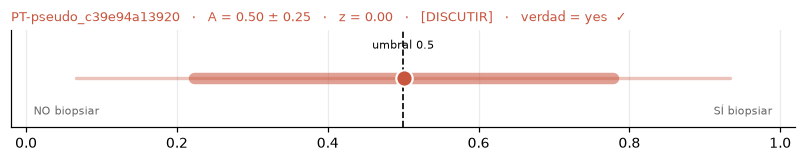

ΔA = 0.245  =  aleatoria 0.235 (los vecinos no concuerdan)  ⊕  epistémica 0.071 (pocos casos parecidos)
vecinos efectivos 1.6 de 10  ·  concordancia 40%  ·  conjunto conformal ['no'] al 80%

→ A ± ΔA cruza 0.5: el recomendador NO distingue. Escribir el número en la pizarra como punto de partida y dejar que los demás expertos lo muevan; aquí acierta poco más que la clase mayoritaria.
→ En validación cruzada, el tramo 'discutir' acertó 61% de las veces.

Los pacientes que sostienen esta opinión (la evidencia que el LLM puede citar):


case_id,decisión,dist,pirads,bx_ord,psa,age,psad,dre_ord,vol,n_pmhx
→ ESTE CASO,yes,0.000000,3.000000,3.000000,12.400000,67.000000,0.080000,0.000000,149.000000,4.000000
PT-pseudo_47d8b39fd07f,no,2.794000,3.000000,1.000000,21.000000,60.000000,0.190000,0.000000,112.150000,2.000000
PT-pseudo_2e0346bce3b3,yes,3.297000,4.000000,3.000000,3.500000,64.000000,0.010000,0.000000,99.000000,1.000000
PT-pseudo_36c92fb424ac,yes,3.381000,4.000000,1.000000,6.000000,67.000000,0.080000,0.000000,79.000000,5.000000
PT-pseudo_075dd468b384,yes,3.456000,4.000000,3.000000,13.200000,66.000000,0.140000,1.000000,96.000000,2.000000
PT-pseudo_c13fda040310,yes,3.521000,4.000000,1.000000,6.100000,63.000000,0.080000,0.000000,73.000000,4.000000


In [5]:
s_discutir = ficha('PT-pseudo_c39e94a13920', verdad='yes')

### 2.2 `firme` — el recomendador se moja

Aquí $A \pm 1.96\,\Delta A$ se queda entero por encima de 0.5. En validación cruzada, los
casos de este tramo se acertaron **todos** (14 de 14). Los cinco vecinos coinciden en
decisión y están cerca: poca $\Delta A$ aleatoria y poca epistémica a la vez.


──────────────────────────────────────────────────────────────────────────────
PT-pseudo_4e545d350c5b  ·  SÍ biopsiar  ·  p(biopsia=yes) = 0.89 ± 0.10  (IC95 0.62–1.00)  ·  firme
──────────────────────────────────────────────────────────────────────────────


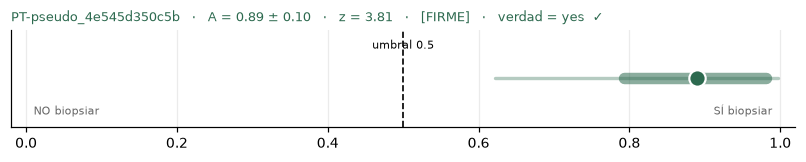

ΔA = 0.102  =  aleatoria 0.097 (los vecinos no concuerdan)  ⊕  epistémica 0.033 (pocos casos parecidos)
vecinos efectivos 8.1 de 10  ·  concordancia 100%  ·  conjunto conformal ['yes'] al 80%

→ A ± 1.96·ΔA no cruza 0.5: el recomendador se moja. En validación este tramo no falló ninguno de los 13 casos, pero son 13: el IC95 del acierto llega solo hasta 0.75 por abajo.
→ En validación cruzada, el tramo 'firme' acertó 100% de las veces.

Los pacientes que sostienen esta opinión (la evidencia que el LLM puede citar):


case_id,decisión,dist,pirads,bx_ord,psa,age,psad,dre_ord,vol,n_pmhx
→ ESTE CASO,yes,0.000000,5.000000,0.000000,22.000000,68.000000,0.696000,0.000000,31.630000,0.000000
PT-pseudo_3f75ae876abe,yes,0.548000,5.000000,0.000000,16.800000,69.000000,0.850000,0.000000,19.860000,0.000000
PT-pseudo_33c8cd4571fd,yes,1.050000,5.000000,0.000000,12.000000,71.000000,0.410000,0.000000,29.200000,1.000000
PT-pseudo_25007bb807d7,yes,1.094000,5.000000,0.000000,17.000000,61.000000,0.460000,0.000000,36.820000,0.000000
PT-pseudo_0de7e606ca70,yes,1.137000,5.000000,0.000000,9.000000,65.000000,0.410000,0.000000,22.030000,1.000000
PT-pseudo_dcd7bf13a6f4,yes,1.215000,5.000000,0.000000,6.770000,74.000000,0.240000,0.000000,28.270000,0.000000


In [6]:
s_firme = ficha('PT-pseudo_4e545d350c5b', verdad='yes')

### 2.3 `apoya` — y además se equivoca: el caso de la consigna

Este es `PT-pseudo_0bd72f429a8b`, el caso que pedía la especificación. La herramienta dice
**no biopsiar** con $A = 0.27 \pm 0.18$ y la verdad es `yes`. Conviene mirarlo de cerca,
porque explica el mecanismo del fallo mejor que cualquier métrica agregada.

Sus cinco vecinos son todos PI-RADS 5 con biopsia previa positiva **a los que no se
biopsió**: pacientes ya diagnosticados y en seguimiento, donde repetir la biopsia no aporta.
El caso consultado comparte `bx = Positive`, pero es PI-RADS **4**, tiene 56 años y un PSA
que sube rápido (`psav` = 2.26) — y esa velocidad de PSA **no está entre las 8 variables**.
El urólogo escribió literalmente *"PIRADS 4 in a young man with a rapid increasing PSA"*.

Es decir: el fallo no es aleatorio, es una **variable que falta**. Y es exactamente la
información que otro experto del sistema puede aportar en la discusión posterior. Que el
tramo sea `apoya` y no `firme` es lo que deja esa puerta abierta.

(Nótese `caso_en_entrenamiento: true` en la salida de la sección 1: este caso está entre los
91 etiquetados, así que la herramienta lo excluye de sus propios vecinos. Sin esa exclusión
se vería a sí mismo y respondería `yes` con confianza falsa.)


──────────────────────────────────────────────────────────────────────────────
PT-pseudo_0bd72f429a8b  ·  NO biopsiar  ·  p(biopsia=yes) = 0.27 ± 0.18  (IC95 0.02–0.69)  ·  apoya
──────────────────────────────────────────────────────────────────────────────


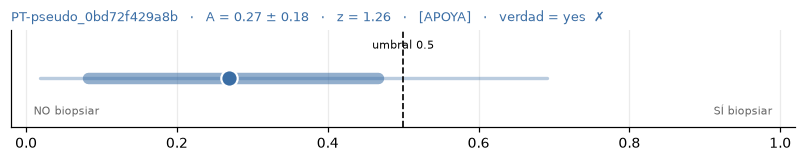

ΔA = 0.183  =  aleatoria 0.154 (los vecinos no concuerdan)  ⊕  epistémica 0.100 (pocos casos parecidos)
vecinos efectivos 5.2 de 10  ·  concordancia 80%  ·  conjunto conformal ['no'] al 80%

→ A ± ΔA no cruza 0.5: hay una dirección clara pero no cerrada. Sirve como voto con peso, no como decisión.
→ En validación cruzada, el tramo 'apoya' acertó 80% de las veces.

Los pacientes que sostienen esta opinión (la evidencia que el LLM puede citar):


case_id,decisión,dist,pirads,bx_ord,psa,age,psad,dre_ord,vol,n_pmhx
→ ESTE CASO,yes,0.000000,4.000000,3.000000,5.300000,56.000000,0.100000,1.000000,48.000000,1.000000
PT-pseudo_c9d31197c533,no,1.646000,5.000000,3.000000,10.920000,61.000000,0.260000,1.000000,42.000000,2.000000
PT-pseudo_34647958aba3,no,1.849000,5.000000,3.000000,7.600000,65.000000,0.120000,1.000000,63.000000,1.000000
PT-pseudo_d38917f87b35,no,1.992000,5.000000,3.000000,28.300000,61.000000,0.400000,1.000000,70.000000,2.000000
PT-pseudo_2b3ef1d3a505,no,2.132000,5.000000,3.000000,4.200000,67.000000,0.060000,1.000000,69.000000,1.000000
PT-pseudo_17f110c9e142,no,2.150000,5.000000,3.000000,6.900000,67.000000,0.170000,1.000000,40.330000,0.000000


In [7]:
s_apoya = ficha('PT-pseudo_0bd72f429a8b', verdad='yes')


──────────────────────────────────────────────────────────────────────────────
2.4  Los tres, uno al lado del otro
──────────────────────────────────────────────────────────────────────────────


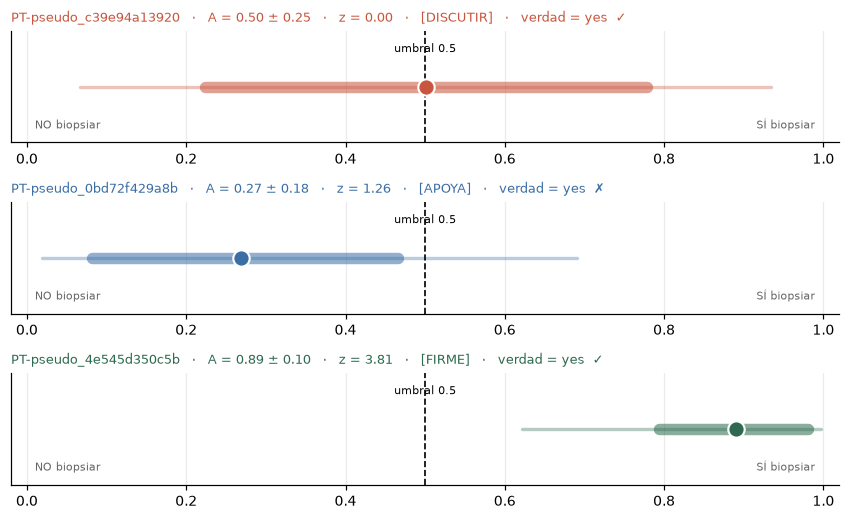

La longitud de la barra ES la información: el recomendador no vale lo mismo en los tres.


In [8]:
caja('2.4  Los tres, uno al lado del otro')
fig, axes = plt.subplots(3, 1, figsize=(7.8, 4.8))
for ax, (s, v) in zip(axes, [(s_discutir, 'yes'), (s_apoya, 'yes'), (s_firme, 'yes')]):
    pizarra(s, ax=ax, verdad=v)
plt.tight_layout(); plt.show()
print('La longitud de la barra ES la información: el recomendador no vale lo mismo en los tres.')

## 3. Resultados sobre toda la base de datos

Dos evaluaciones distintas, y conviene no confundirlas:

* **3.1–3.5 · los 91 casos etiquetados**, con probabilidades *out-of-fold* (CV 5×5): es la
  única cifra honesta de rendimiento, porque ningún caso participó en el modelo que lo juzga.
* **3.6 · los 195 casos completos**, con el modelo final: no hay verdad para 104 de ellos,
  así que ahí solo se mira **cómo se reparte la confianza en producción**.

In [9]:
# --- 3.0 Recuperar la validación out-of-fold guardada en el artefacto ---
oof = E['oof']
d = pd.DataFrame({'case_id': oof['ids'], 'real': oof['y'], 'A': oof['A'],
                  'delta': oof['delta'], 'delta_ale': oof['delta_ale'],
                  'delta_epi': oof['delta_epi']})
d['pred'] = np.where(d.A >= .5, 'yes', 'no')
d['ok'] = d.pred == d.real
d['z'] = (d.A - .5).abs() / d.delta
d['tramo'] = np.where(d.z >= E['z_firme'], 'firme',
                      np.where(d.z >= E['z_apoya'], 'apoya', 'discutir'))

caja('3.1  Rendimiento out-of-fold (5×5 CV) sobre los 91 etiquetados')
display(pd.Series(E['metricas']).to_frame('valor'))
print(f"La clase mayoritaria acierta {E['metricas']['clase_mayoritaria']:.3f}; "
      f"el recomendador {E['metricas']['acc']:.3f}.")
print('Es una ganancia modesta, y era de esperar: el §2.2 del notebook de expertos midió que')
print('el 36 % de los casos de T1 no son "clear" ni para el propio urólogo que los etiquetó.')
print('Hay un techo de acuerdo inter-observador metido en las etiquetas.')


──────────────────────────────────────────────────────────────────────────────
3.1  Rendimiento out-of-fold (5×5 CV) sobre los 91 etiquetados
──────────────────────────────────────────────────────────────────────────────


,valor
n,91
clase_mayoritaria,0.615
acc,0.703
bal_acc,0.662
auc,0.75
logloss,0.573
brier,0.197
ece,0.095
acc@30%,0.926
acc@50%,0.778


La clase mayoritaria acierta 0.615; el recomendador 0.703.
Es una ganancia modesta, y era de esperar: el §2.2 del notebook de expertos midió que
el 36 % de los casos de T1 no son "clear" ni para el propio urólogo que los etiquetó.
Hay un techo de acuerdo inter-observador metido en las etiquetas.



──────────────────────────────────────────────────────────────────────────────
3.2  La escalera operativa: para qué sirve de verdad ΔA
──────────────────────────────────────────────────────────────────────────────


,n,acc,A_medio,delta_medio,% casos,IC95 del acierto
tramo,,,,,,
firme,14,1.000,0.853,0.124,15%,"[0.768, 1.0]"
apoya,15,0.800,0.739,0.168,16%,"[0.519, 0.957]"
discutir,62,0.613,0.518,0.206,68%,"[0.481, 0.734]"


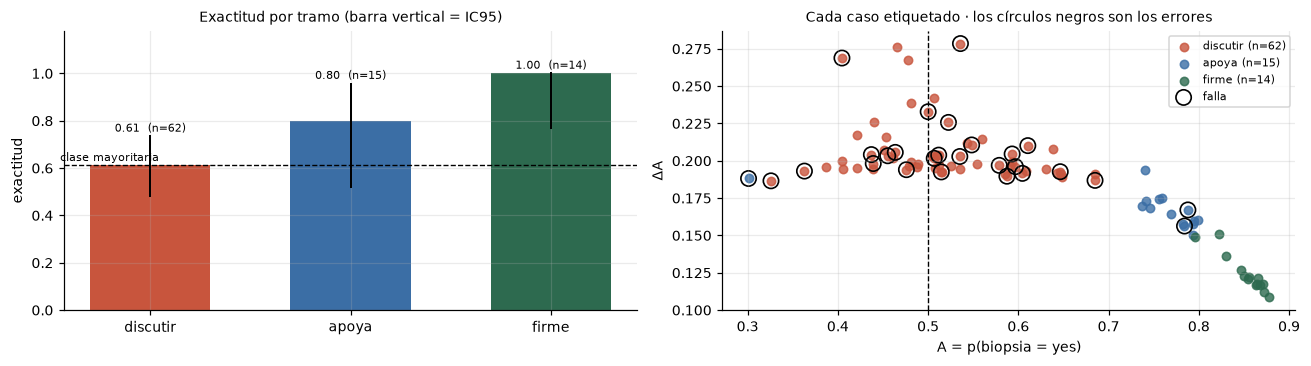


Lo que hay que leer aquí: la exactitud sube de forma monótona 0.61 → 0.80 → 1.00 conforme A
se aleja de 0.5 medido EN UNIDADES DE ΔA. Ese orden es el producto real de la herramienta;
la exactitud global (0.703) es lo de menos.

Y una limitación que no se puede maquillar: los 14 casos "firme" son TODOS predicciones
`yes`. El recomendador nunca se pone firme en "no biopsiar" — solo sabe empujar hacia la
biopsia con seguridad. Clínicamente es la dirección prudente, pero hay que decirlo.



In [10]:
caja('3.2  La escalera operativa: para qué sirve de verdad ΔA')
tab = (d.groupby('tramo')
         .agg(n=('ok', 'size'), acc=('ok', 'mean'), A_medio=('A', 'mean'),
              delta_medio=('delta', 'mean'))
         .reindex(['firme', 'apoya', 'discutir']).round(3))
tab['% casos'] = (tab.n / len(d)).map('{:.0%}'.format)
tab['IC95 del acierto'] = [E['ic_tramos'][t] for t in tab.index]
display(tab)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
ax = axes[0]
orden = ['discutir', 'apoya', 'firme']
ax.bar(orden, [tab.loc[t, 'acc'] for t in orden], color=[COL_TRAMO[t] for t in orden], width=.6)
for i, t in enumerate(orden):
    lo, hi = E['ic_tramos'][t]
    ax.plot([i, i], [lo, hi], color='k', lw=1.3)
    ax.text(i, hi + .02, f"{tab.loc[t,'acc']:.2f}  (n={tab.loc[t,'n']})", ha='center', fontsize=7.5)
ax.axhline(E['metricas']['clase_mayoritaria'], ls='--', c='k', lw=.9)
ax.text(-.45, E['metricas']['clase_mayoritaria'] + .015, 'clase mayoritaria', fontsize=7)
ax.set_ylim(0, 1.18); ax.set_ylabel('exactitud')
ax.set_title('Exactitud por tramo (barra vertical = IC95)', fontsize=9)

ax = axes[1]
for t in orden:
    g = d[d.tramo == t]
    ax.scatter(g.A, g.delta, s=30, alpha=.8, color=COL_TRAMO[t], label=f'{t} (n={len(g)})')
mal = d[~d.ok]
ax.scatter(mal.A, mal.delta, s=100, facecolors='none', edgecolors='k', lw=1.1, label='falla')
ax.axvline(.5, ls='--', c='k', lw=.9)
ax.set_xlabel('A = p(biopsia = yes)'); ax.set_ylabel('ΔA')
ax.set_title('Cada caso etiquetado · los círculos negros son los errores', fontsize=9)
ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

print("""
Lo que hay que leer aquí: la exactitud sube de forma monótona 0.61 → 0.80 → 1.00 conforme A
se aleja de 0.5 medido EN UNIDADES DE ΔA. Ese orden es el producto real de la herramienta;
la exactitud global (0.703) es lo de menos.

Y una limitación que no se puede maquillar: los 14 casos "firme" son TODOS predicciones
`yes`. El recomendador nunca se pone firme en "no biopsiar" — solo sabe empujar hacia la
biopsia con seguridad. Clínicamente es la dirección prudente, pero hay que decirlo.
""")


──────────────────────────────────────────────────────────────────────────────
3.3  ¿Vale lo que dice? Calibración y riesgo–cobertura
──────────────────────────────────────────────────────────────────────────────


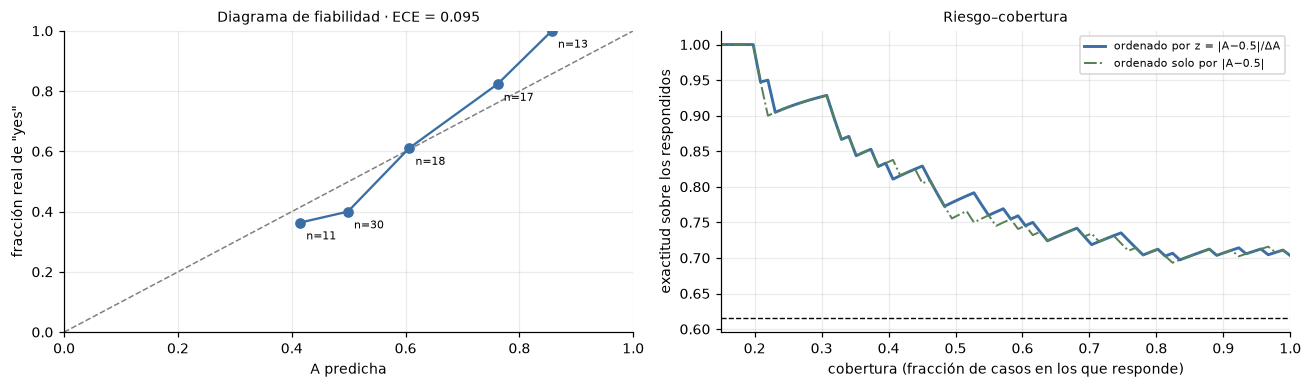


· Calibración: los puntos caen POR ENCIMA de la diagonal en el extremo alto — el
  recomendador es infra-confiado: dice 0.85 donde la realidad es 1.00. Se probó recalibrar
  (Platt de 2 parámetros) y, evaluado leave-one-out, bajaba la exactitud de 0.703 a 0.670 a
  cambio de 3 puntos de ECE: con n=91 no compensa. Se sirve A sin recalibrar, y su sesgo es
  hacia la prudencia, que para una pizarra es el lado correcto en el que fallar.

· Riesgo–cobertura: al 30 % de cobertura la exactitud es 0.926; al 50 %,
  0.778. Dividir por ΔA (línea sólida) ordena mejor que usar solo la distancia
  de A al umbral (línea de puntos): ΔA aporta información propia, no es un adorno.



In [11]:
caja('3.3  ¿Vale lo que dice? Calibración y riesgo–cobertura')
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

ax = axes[0]
bordes = np.array([0, .35, .45, .55, .65, .8, 1.001])
xs, ys, ns = [], [], []
for lo, hi in zip(bordes[:-1], bordes[1:]):
    m = (d.A >= lo) & (d.A < hi)
    if m.sum() >= 3:
        xs.append(d.A[m].mean()); ys.append((d.real[m] == 'yes').mean()); ns.append(int(m.sum()))
ax.plot([0, 1], [0, 1], ls='--', c='grey', lw=1)
ax.plot(xs, ys, 'o-', color=PAL[0], ms=6)
for x, y_, n in zip(xs, ys, ns):
    ax.annotate(f'n={n}', (x, y_), fontsize=7, textcoords='offset points', xytext=(4, -11))
ax.set_xlabel('A predicha'); ax.set_ylabel('fracción real de "yes"')
ax.set_title(f"Diagrama de fiabilidad · ECE = {E['metricas']['ece']:.3f}", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

ax = axes[1]
z = np.abs(d.A - .5) / d.delta
o = np.argsort(-z.to_numpy())
cov = np.arange(1, len(d) + 1) / len(d)
ax.plot(cov, np.cumsum(d.ok.to_numpy()[o]) / np.arange(1, len(d) + 1),
        lw=1.9, color=PAL[0], label='ordenado por z = |A−0.5|/ΔA')
o2 = np.argsort(-np.abs(d.A - .5).to_numpy())
ax.plot(cov, np.cumsum(d.ok.to_numpy()[o2]) / np.arange(1, len(d) + 1),
        lw=1.3, ls='-.', color=PAL[2], label='ordenado solo por |A−0.5|')
ax.axhline(E['metricas']['clase_mayoritaria'], ls='--', c='k', lw=.9)
ax.set_xlim(.15, 1); ax.set_xlabel('cobertura (fracción de casos en los que responde)')
ax.set_ylabel('exactitud sobre los respondidos')
ax.set_title('Riesgo–cobertura', fontsize=9); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

print(f"""
· Calibración: los puntos caen POR ENCIMA de la diagonal en el extremo alto — el
  recomendador es infra-confiado: dice 0.85 donde la realidad es 1.00. Se probó recalibrar
  (Platt de 2 parámetros) y, evaluado leave-one-out, bajaba la exactitud de 0.703 a 0.670 a
  cambio de 3 puntos de ECE: con n=91 no compensa. Se sirve A sin recalibrar, y su sesgo es
  hacia la prudencia, que para una pizarra es el lado correcto en el que fallar.

· Riesgo–cobertura: al 30 % de cobertura la exactitud es {E['metricas']['acc@30%']:.3f}; al 50 %,
  {E['metricas']['acc@50%']:.3f}. Dividir por ΔA (línea sólida) ordena mejor que usar solo la distancia
  de A al umbral (línea de puntos): ΔA aporta información propia, no es un adorno.
""")


──────────────────────────────────────────────────────────────────────────────
3.4  Las dos incertidumbres: ¿cuál detecta los errores?
──────────────────────────────────────────────────────────────────────────────


medida,AUC como detector de error
ΔA total,0.661000
ΔA aleatoria,0.621000
ΔA epistémica (bagging),0.679000
"confianza max(A, 1−A)",0.634000


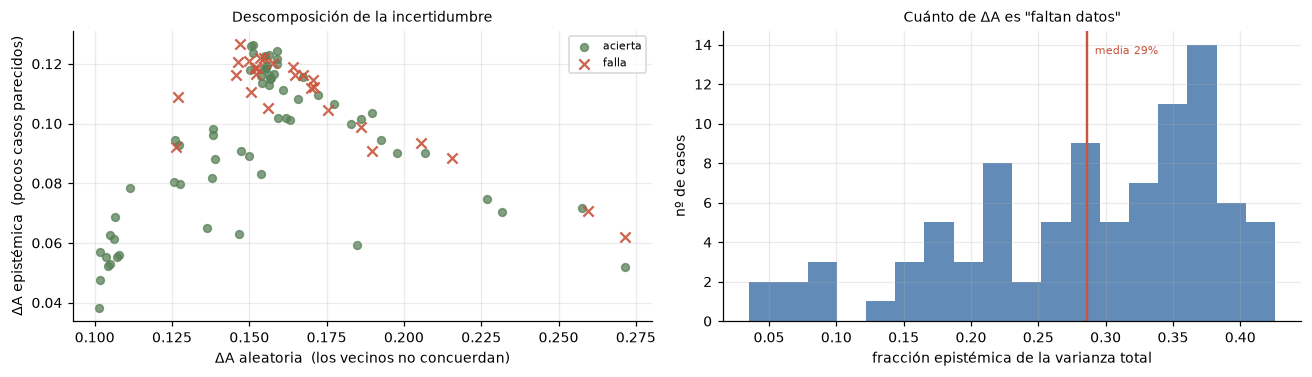


Resultado que corrige al notebook previo: allí la incertidumbre epistémica se medía con la
densidad local del núcleo gaussiano y NO detectaba errores (AUC 0.53 = azar, §8.4). La
epistémica del bagging alcanza AUC 0.679: sí los detecta, y es la componente
más informativa de las dos.

Interpretación: con 91 casos en 8 dimensiones casi todos los puntos son "raros", así que la
densidad no tiene contraste que medir. Lo que sí varía de un caso a otro es cuánto se movería
la respuesta si el conjunto de entrenamiento hubiera sido otro — y eso es exactamente lo que
mide el remuestreo. Un 29% de la varianza total es epistémica, es decir, reducible con
más datos etiquetados.



In [12]:
caja('3.4  Las dos incertidumbres: ¿cuál detecta los errores?')
from sklearn.metrics import roc_auc_score
err = (~d.ok).astype(int)
comp = pd.DataFrame([
    {'medida': 'ΔA total',                   'AUC como detector de error': roc_auc_score(err, d.delta)},
    {'medida': 'ΔA aleatoria',               'AUC como detector de error': roc_auc_score(err, d.delta_ale)},
    {'medida': 'ΔA epistémica (bagging)',    'AUC como detector de error': roc_auc_score(err, d.delta_epi)},
    {'medida': 'confianza  max(A, 1−A)',     'AUC como detector de error': roc_auc_score(err, -np.maximum(d.A, 1 - d.A))},
]).round(3)
display(comp.style.hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
ax = axes[0]
ax.scatter(d.delta_ale[d.ok], d.delta_epi[d.ok], s=26, alpha=.75, color=PAL[2], label='acierta')
ax.scatter(d.delta_ale[~d.ok], d.delta_epi[~d.ok], s=45, alpha=.9, color=PAL[1], marker='x', label='falla')
ax.set_xlabel('ΔA aleatoria  (los vecinos no concuerdan)')
ax.set_ylabel('ΔA epistémica  (pocos casos parecidos)')
ax.set_title('Descomposición de la incertidumbre', fontsize=9); ax.legend(fontsize=7)

ax = axes[1]
frac = (d.delta_epi ** 2) / (d.delta ** 2)
ax.hist(frac, bins=18, color=PAL[0], alpha=.8)
ax.axvline(frac.mean(), color=PAL[1], lw=1.6)
ax.text(frac.mean(), ax.get_ylim()[1] * .92, f'  media {frac.mean():.0%}', fontsize=7.5, color=PAL[1])
ax.set_xlabel('fracción epistémica de la varianza total'); ax.set_ylabel('nº de casos')
ax.set_title('Cuánto de ΔA es "faltan datos"', fontsize=9)
plt.tight_layout(); plt.show()

print(f"""
Resultado que corrige al notebook previo: allí la incertidumbre epistémica se medía con la
densidad local del núcleo gaussiano y NO detectaba errores (AUC 0.53 = azar, §8.4). La
epistémica del bagging alcanza AUC {roc_auc_score(err, d.delta_epi):.3f}: sí los detecta, y es la componente
más informativa de las dos.

Interpretación: con 91 casos en 8 dimensiones casi todos los puntos son "raros", así que la
densidad no tiene contraste que medir. Lo que sí varía de un caso a otro es cuánto se movería
la respuesta si el conjunto de entrenamiento hubiera sido otro — y eso es exactamente lo que
mide el remuestreo. Un {frac.mean():.0%} de la varianza total es epistémica, es decir, reducible con
más datos etiquetados.
""")

In [13]:
caja('3.5  Garantía formal: el conjunto conformal Mondrian (cobertura objetivo 80 %)')
P = np.stack([1 - d.A.to_numpy(), d.A.to_numpy()], 1)
q = np.array([E['q_conformal']['no'], E['q_conformal']['yes']])
S = (1 - P) <= q[None, :]
tam = S.sum(1)
yb = (d.real == 'yes').astype(int).to_numpy()
cubierto = S[np.arange(len(d)), yb]
display(pd.DataFrame([{
    'cobertura empírica': cubierto.mean(),
    'tamaño medio del conjunto': tam.mean(),
    '% respuesta única': (tam == 1).mean(),
    'exactitud cuando es única': (cubierto & (tam == 1)).sum() / max((tam == 1).sum(), 1),
    '% conjunto vacío': (tam == 0).mean(),
}]).round(3).style.hide(axis='index'))
print("""
Cuando el conjunto conformal trae las DOS clases, el mensaje al agente es literal: "con la
cobertura que me has pedido no puedo elegir entre biopsiar y no biopsiar". Eso es
información, no un fallo — y es complementaria a ΔA: el conformal da una garantía de
cobertura, ΔA da una magnitud continua que se puede escribir en la pizarra y discutir.
""")


──────────────────────────────────────────────────────────────────────────────
3.5  Garantía formal: el conjunto conformal Mondrian (cobertura objetivo 80 %)
──────────────────────────────────────────────────────────────────────────────


cobertura empírica,tamaño medio del conjunto,% respuesta única,exactitud cuando es única,% conjunto vacío
0.824000,1.253000,0.747000,0.765000,0.000000



Cuando el conjunto conformal trae las DOS clases, el mensaje al agente es literal: "con la
cobertura que me has pedido no puedo elegir entre biopsiar y no biopsiar". Eso es
información, no un fallo — y es complementaria a ΔA: el conformal da una garantía de
cobertura, ΔA da una magnitud continua que se puede escribir en la pizarra y discutir.




──────────────────────────────────────────────────────────────────────────────
3.6  Los 195 casos completos: cómo se reparte la confianza en producción
──────────────────────────────────────────────────────────────────────────────


195 casos servidos (91 etiquetados, 104 sin etiqueta).
Casos con alguna variable ausente: 6 (se imputa con la mediana y ΔA lo absorbe).


pred,no,yes,total,% casos
tramo,,,,
firme,0,27,27,14%
apoya,3,20,23,12%
discutir,64,81,145,74%


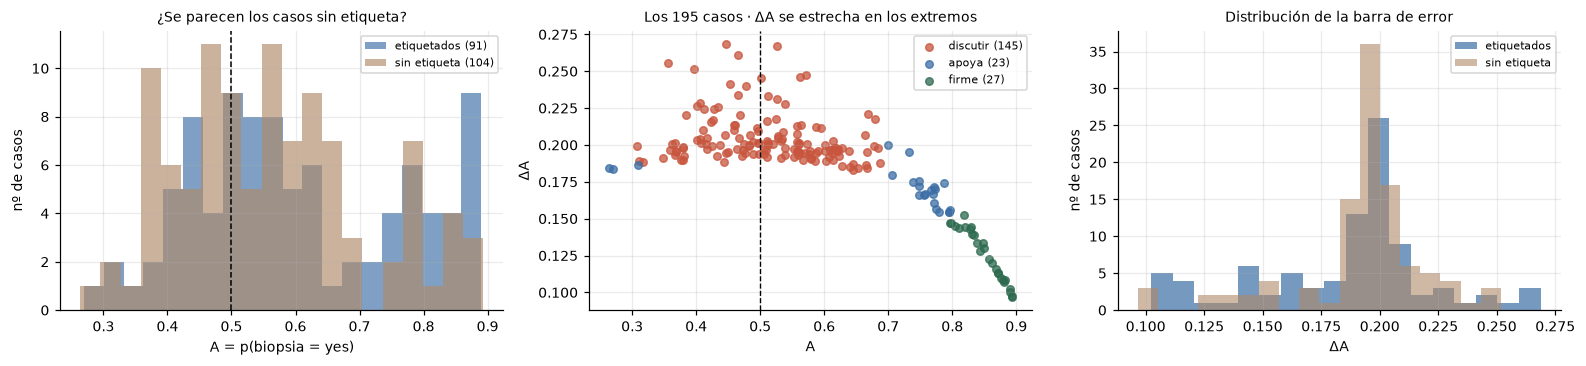


Comprobación de que los casos sin etiqueta no son un mundo aparte: la distribución de ΔA en
los 104 sin etiqueta frente a los 91 de entrenamiento da Kolmogorov–Smirnov D=0.150
(p=0.203). ΔA medio: 0.186 en los etiquetados frente a
0.193 en los que no lo están.

Este es, de hecho, el único uso de la incertidumbre epistémica que el análisis respalda para
casos nuevos: comprobar que caen dentro de lo conocido antes de fiarse del veredicto.



In [14]:
caja('3.6  Los 195 casos completos: cómo se reparte la confianza en producción')
todos = sorted(p.name for p in DATA_T1.iterdir() if p.is_dir())
filas = []
for cid in todos:
    s = rec.recomendar(DATA_T1 / cid / 'structured-prompt.json')
    lab = DATA_T1 / cid / f'{DECISION}.json'
    filas.append({'case_id': cid, 'A': s['A'], 'delta': s['delta_A'],
                  'z': s['incertidumbre']['margen_z'], 'pred': s['prediccion'],
                  'tramo': s['veredicto_operativo'],
                  'n_faltantes': len(s['variables_faltantes']),
                  'real': (json.load(open(lab, encoding='utf-8')) if lab.exists() else None)})
T = pd.DataFrame(filas)
T['etiquetado'] = T.real.notna()
print(f'{len(T)} casos servidos ({T.etiquetado.sum()} etiquetados, {(~T.etiquetado).sum()} sin etiqueta).')
print(f'Casos con alguna variable ausente: {(T.n_faltantes > 0).sum()} '
      f'(se imputa con la mediana y ΔA lo absorbe).')

resumen = (T.groupby(['tramo', 'pred']).size().unstack(fill_value=0)
             .reindex(['firme', 'apoya', 'discutir']))
resumen['total'] = resumen.sum(1)
resumen['% casos'] = (resumen.total / len(T)).map('{:.0%}'.format)
display(resumen)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.4))
ax = axes[0]
for et, nom, c in [(True, 'etiquetados (91)', PAL[0]), (False, 'sin etiqueta (104)', PAL[3])]:
    ax.hist(T.A[T.etiquetado == et], bins=20, alpha=.65, color=c, label=nom)
ax.axvline(.5, ls='--', c='k', lw=1)
ax.set_xlabel('A = p(biopsia = yes)'); ax.set_ylabel('nº de casos')
ax.set_title('¿Se parecen los casos sin etiqueta?', fontsize=9); ax.legend(fontsize=7)

ax = axes[1]
for t in ['discutir', 'apoya', 'firme']:
    g = T[T.tramo == t]
    ax.scatter(g.A, g.delta, s=24, alpha=.75, color=COL_TRAMO[t], label=f'{t} ({len(g)})')
ax.axvline(.5, ls='--', c='k', lw=.9)
ax.set_xlabel('A'); ax.set_ylabel('ΔA'); ax.legend(fontsize=7)
ax.set_title('Los 195 casos · ΔA se estrecha en los extremos', fontsize=9)

ax = axes[2]
ax.hist(T.delta[T.etiquetado], bins=18, alpha=.7, color=PAL[0], label='etiquetados')
ax.hist(T.delta[~T.etiquetado], bins=18, alpha=.6, color=PAL[3], label='sin etiqueta')
ax.set_xlabel('ΔA'); ax.set_ylabel('nº de casos'); ax.legend(fontsize=7)
ax.set_title('Distribución de la barra de error', fontsize=9)
plt.tight_layout(); plt.show()

ks = stats.ks_2samp(T.delta[T.etiquetado], T.delta[~T.etiquetado])
print(f"""
Comprobación de que los casos sin etiqueta no son un mundo aparte: la distribución de ΔA en
los 104 sin etiqueta frente a los 91 de entrenamiento da Kolmogorov–Smirnov D={ks.statistic:.3f}
(p={ks.pvalue:.3f}). ΔA medio: {T.delta[T.etiquetado].mean():.3f} en los etiquetados frente a
{T.delta[~T.etiquetado].mean():.3f} en los que no lo están.

Este es, de hecho, el único uso de la incertidumbre epistémica que el análisis respalda para
casos nuevos: comprobar que caen dentro de lo conocido antes de fiarse del veredicto.
""")

In [15]:
caja('3.7  Tabla final: los 91 etiquetados, ordenados por confianza')
vista = (d.assign(**{'A ± ΔA': [f'{a:.2f} ± {b:.2f}' for a, b in zip(d.A, d.delta)]})
          .sort_values('z', ascending=False)
          [['case_id', 'A ± ΔA', 'z', 'tramo', 'pred', 'real', 'ok']]
          .reset_index(drop=True))
print(f'Los 12 más confiados (fallos entre ellos: {(~vista.head(12).ok).sum()}):')
display(vista.head(12).round(2).style.hide(axis='index'))
print('Los 8 en los que el recomendador está más perdido (A ≈ 0.5):')
display(vista.tail(8).round(2).style.hide(axis='index'))
print(f"\nErrores totales: {(~d.ok).sum()} de {len(d)}. De ellos, "
      f"{((~d.ok) & (d.tramo == 'discutir')).sum()} caen en el tramo 'discutir', "
      f"es decir, la herramienta ya avisaba de que no se fiara.")


──────────────────────────────────────────────────────────────────────────────
3.7  Tabla final: los 91 etiquetados, ordenados por confianza
──────────────────────────────────────────────────────────────────────────────
Los 12 más confiados (fallos entre ellos: 0):


case_id,A ± ΔA,z,tramo,pred,real,ok
PT-pseudo_dcd7bf13a6f4,0.88 ± 0.11,3.490000,firme,yes,yes,True
PT-pseudo_33c8cd4571fd,0.87 ± 0.11,3.310000,firme,yes,yes,True
PT-pseudo_152344add0f1,0.87 ± 0.12,3.150000,firme,yes,yes,True
PT-pseudo_4e545d350c5b,0.87 ± 0.12,3.150000,firme,yes,yes,True
PT-pseudo_0de7e606ca70,0.86 ± 0.12,3.120000,firme,yes,yes,True
PT-pseudo_25007bb807d7,0.86 ± 0.12,3.100000,firme,yes,yes,True
PT-pseudo_3f75ae876abe,0.87 ± 0.12,3.000000,firme,yes,yes,True
PT-pseudo_2ef22b5dd08e,0.85 ± 0.12,2.940000,firme,yes,yes,True
PT-pseudo_1185f6a68df0,0.86 ± 0.12,2.910000,firme,yes,yes,True
PT-pseudo_52213169f58b,0.85 ± 0.12,2.860000,firme,yes,yes,True


Los 8 en los que el recomendador está más perdido (A ≈ 0.5):


case_id,A ± ΔA,z,tramo,pred,real,ok
PT-pseudo_d7d26761c714,0.49 ± 0.20,0.060000,discutir,no,no,True
PT-pseudo_1a4e0cf3b927,0.51 ± 0.20,0.060000,discutir,yes,no,False
PT-pseudo_c13fda040310,0.51 ± 0.20,0.050000,discutir,yes,yes,True
PT-pseudo_2fbb84505a45,0.51 ± 0.20,0.040000,discutir,yes,yes,True
PT-pseudo_4f33b0253633,0.51 ± 0.20,0.030000,discutir,yes,no,False
PT-pseudo_c39e94a13920,0.51 ± 0.24,0.030000,discutir,yes,yes,True
PT-pseudo_21e7fa67a79e,0.50 ± 0.20,0.020000,discutir,yes,yes,True
PT-pseudo_d95b3a02898e,0.50 ± 0.23,0.000000,discutir,yes,no,False



Errores totales: 27 de 91. De ellos, 24 caen en el tramo 'discutir', es decir, la herramienta ya avisaba de que no se fiara.


## 4. Límites honestos y cómo debe usarlo el agente

### Lo que esta herramienta es

Un **punto de partida con barra de error**, no un decisor. Su valor no está en la exactitud
global (0.703 frente a 0.615 de la clase mayoritaria: siete casos de 91), sino en que
**ordena bien**: cuando dice que está seguro, lo está.

### Reglas de uso

| Si `veredicto_operativo` es… | El agente debería… |
|---|---|
| `firme` | tomarlo como voto fuerte; en validación no falló ninguno de los 14 casos, aunque el IC95 del acierto baja hasta 0.77 |
| `apoya` | escribirlo en la pizarra como voto con peso y **buscar activamente lo que pueda contradecirlo** — el caso de la sección 2.3 es exactamente eso |
| `discutir` | escribir el número, no la conclusión: aquí acierta 0.61, apenas por encima del azar informado |

### Límites que no se pueden maquillar

1. **n = 91.** Diferencias menores de ~0.03 en exactitud no se distinguen del ruido. El tramo
   `firme` tiene 14 casos: el 1.00 es real, pero su IC95 llega solo hasta 0.77 por abajo.
2. **Nunca se pone firme en "no biopsiar".** Los 14 `firme` son todos `yes` (§3.2). La
   herramienta sabe empujar hacia la biopsia con seguridad; no sabe descartarla.
3. **Hay un techo en las propias etiquetas.** El 36 % de los casos de T1 no son `clear` ni
   para el urólogo que los etiquetó (§2.2 del notebook de expertos). Un clasificador que
   aspirase a 0.95 aquí estaría ajustando ruido.
4. **Le faltan variables a propósito.** No ve la velocidad de PSA, ni la tendencia histórica,
   ni el informe de radiología. El fallo de la sección 2.3 es precisamente eso. La respuesta
   correcta no es meterlas todas — el §4.2 del notebook previo midió que el ruido daña a la
   distancia del kNN — sino **dejar que otro experto las aporte en la discusión**.
5. **No hay conjunto de test independiente.** Todo es CV repetida. El núcleo de variables se
   fijó con los `reasoning.json` (conocimiento externo, no la respuesta) y `k` se fijó por la
   regla $k=\sqrt{n}$ sin mirar el resultado, pero el diseño global sí ha visto esta misma
   validación: las cifras son optimistas.
6. **A está infra-calibrada** (ECE 0.095, sesgo hacia el centro). Se decidió no recalibrar:
   con n=91 el Platt evaluado leave-one-out costaba más exactitud de la que arreglaba.

### Siguiente paso natural

Este es el `recomendador_inicial`. El hermano que falta es `recomendador_con_historia`: el
mismo contrato de salida, pero con acceso a `prostate-biopsy-decision-clinical-data.json`.
La comparación entre los dos es lo que dirá si revelar documentos compensa su coste en
`tool_score` — y el caso de la sección 2.3, donde la velocidad de PSA habría cambiado la
respuesta, sugiere que al menos en algunos casos sí.